# 2025 0225 분포를 이용해서 그리기

In [1]:
# midpoint의 TES는 멕센트로 만든 자료이다.

### 필요한 라이브러리

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import pickle
import numpy.random as rand
import h5py
import time
from tqdm import tqdm

### 필요한 데이터

작업을 수행할 기본 위치 : base

CA를 학습시킨 CNN의 위치와 종류 선택(128, 256, 76) : model

분석하고 싶은 종 이름 : species

멕센트 데이터를 행정구역별로 가공한 데이터 위치와 종류 선택(midpoint, lhs) : sampling

사용할 시나리오 : scenarios

seed_num

### 아래 셀을 설정해야합니다.

In [ ]:
base = ‘슈퍼컴CA_2025'
model = '/model/128' #모델 종류 선택 (76, 128, 256, 152)
species = '/TES_maxent' #분석하고 싶은 종 선택 (TES)
sampling = '/data/latin' #샘플링 방법 선택 (midpoint, latin)
scenario = ['126', '126', '126', '126'] #시나리오 선택
seeed_num = 10

### 아래는 설정 안해도 됩니다.

In [3]:
# 데이터 불러오기
if sampling == '/data/latin':
    local_index = pd.read_csv(base+sampling+'/local_index.csv')
    local_name = local_index["SIG_ENG_NM"].tolist()
    with open(base+sampling+species+'/all.pkl', 'rb') as file:
        local_all = pickle.load(file)
    with open(base+sampling+species+'/sampling.pkl', 'rb') as file:
        local_lhs = pickle.load(file)
else :
    local_index = pd.read_csv(base+sampling+'/local_index.csv')
    local_name = local_index.columns.tolist()

In [4]:
# 모델 불러오기
if '152' == model[7:]:
    model_dir = [base+model+'/p1.keras', base+model+'/p2.keras', base+model+'/p3.keras', base+model+'/p4.keras', base+model+'/p5.keras']
else:
    model_dir = [base+model+'/p1', base+model+'/p2', base+model+'/p3', base+model+'/p4', base+model+'/p5']

### lhs sampling 일때, 행정구역별 샘플링을 확인해 보자

확인해보고 싶은 도시의 인덱스를 찾아서 k에 바운딩

In [5]:
for i, name in enumerate(local_name):
    print(f"{i}:{name}", end=" | ")

0:Goseong-gun2 | 1:Inje-gun1 | 2:Cheorwon-gun | 3:Yanggu-gun | 4:Hwacheon-gun | 5:Yeoncheon-gun | 6:Sokcho-si | 7:Pocheon-si | 8:Yangyang-gun | 9:Chuncheon-si | 10:Gapyeong-gun | 11:Paju-si | 12:Ongjin-gun | 13:Dongducheon-si | 14:Hongcheon-gun | 15:Yangju-si | 16:Gangneung-si | 17:Ganghwa-gun | 18:Pyeongchang-gun | 19:Uijeongbu-si | 20:Namyangju-si | 21:Gimpo-si | 22:Goyang-si | 23:Seoul-si | 24:Hoengseong-gun | 25:Yangpyeong-gun | 26:Guri-si | 27:Incheon-si | 28:Donghae-si | 29:Hanam-si | 30:Jeongseon-gun | 31:Bucheon-si | 32:Gwangju-si2 | 33:Ulleung-gun | 34:Wonju-si | 35:Gwangmyeong-si | 36:Siheung-si | 37:Seongnam-si | 38:Samcheok-si | 39:Gwacheon-si | 40:Anyang-si | 41:Yeoju-si | 42:Uiwang-si | 43:Yeongwol-gun | 44:Gunpo-si | 45:Ansan-si | 46:Yongin-si | 47:Icheon-si | 48:Suwon-si | 49:Taebaek-si | 50:Hwaseong-si | 51:Jecheon-si | 52:Chungju-si | 53:Osan-si | 54:Anseong-si | 55:Eumseong-gun | 56:Danyang-gun | 57:Pyeongtaek-si | 58:Uljin-gun | 59:Bonghwa-gun | 60:Yeongju-si | 61:D

In [6]:
# 인덱스 k의 행정구역에 대해서 보자.
k = 20
print(local_name[k])

Namyangju-si


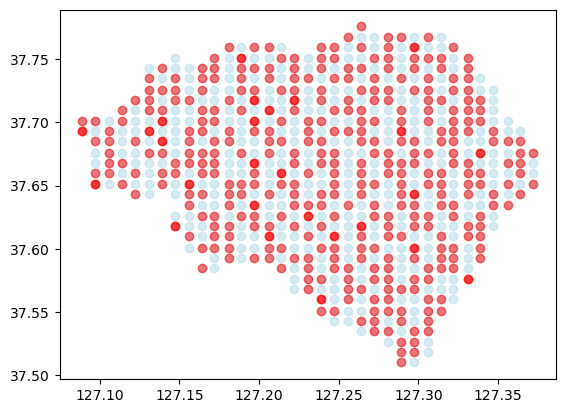

In [7]:
aa = local_all["ssp245_2050"][local_name[k]] #시나리오, 연도에 상관 없음
bb = local_lhs["ssp245_2050"][local_name[k]]

plt.scatter(aa['x'], aa['y'], color='lightblue', label='All Data', alpha=0.5)
plt.scatter(bb['x'], bb['y'], color='red', label='All Data', alpha=0.5)

### 멕센트 데이터를 가져와 20by20의 행렬 데이터를 만드는 함수

In [5]:
#lhs
def lhs_make_maxent_mat(scenario, loc):
    maxent_mat = []
    for i in ["ssp"+str(scenario[0])+"_2030", "ssp"+str(scenario[1])+"_2050",
              "ssp"+str(scenario[2])+"_2070", "ssp"+str(scenario[3])+"_2090"]:
        dataF = local_lhs[i][loc]
        dataF = dataF.iloc[:,2]
        dataF = np.reshape(dataF,(20,20))
        maxent_mat.append(dataF)
        
    maxent_mat = np.array(maxent_mat)
    maxent_mat = np.transpose(maxent_mat,(1,2,0))
    maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
    return maxent_mat

#midpoint
def midpoint_make_maxent_mat(scenrio,loc):
    maxent_mat = []
    loc_num = local_index.columns.get_loc(loc)
    for i in ["ssp"+str(scenario[0])+"_2030.csv", "ssp"+str(scenario[1])+"_2050.csv", 
              "ssp"+str(scenario[2])+"_2070.csv", "ssp"+str(scenario[3])+"_2090.csv"]:
        dataF = pd.read_csv(base+sampling+species+"/"+i)
        dataF = dataF.fillna(0)
        dataF = dataF.iloc[:,:].values
        dataF = dataF[dataF[:,0]>local_index.iloc[0, loc_num]]
        dataF = dataF[dataF[:,0]<local_index.iloc[1, loc_num]]
        dataF = dataF[dataF[:,1]>local_index.iloc[2, loc_num]]
        dataFF = dataF[dataF[:,1]<local_index.iloc[3, loc_num]]
        dataFF = dataFF[0:400,2]
        dataFF = np.reshape(dataFF,(20,20))
        maxent_mat.append(dataFF)
        
    maxent_mat = np.array(maxent_mat)
    maxent_mat = np.transpose(maxent_mat,(1,2,0))
    maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
    return maxent_mat

def make_maxent_mat(scenario, loc):
    if sampling == '/data/latin':
        return lhs_make_maxent_mat(scenario, loc)
    else:
        return midpoint_make_maxent_mat(scenario, loc)

In [6]:
# 데이터가 이상해서 잠깐 만들었던 코드
# # lhs
# def lhs_make_maxent_mat(scenario, loc):
#     maxent_mat = []
#     for i in ["ssp"+str(scenario[0])+"_2030", "ssp"+str(scenario[1])+"_2050",
#               "ssp"+str(scenario[2])+"_2070", "ssp"+str(scenario[3])+"_2090"]:
#         dataF = local_lhs[i][loc]
#         dataF = dataF.iloc[:,2]
#         dataF = np.reshape(dataF,(20,20))
#         maxent_mat.append(dataF)
        
#     maxent_mat = np.array(maxent_mat)
#     maxent_mat = np.transpose(maxent_mat,(1,2,0))
#     maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
#     return maxent_mat

# #midpoint
# def midpoint_make_maxent_mat(scenrio,loc):
#     maxent_mat = []
#     loc_num = local_index.columns.get_loc(loc)
#     for i in ["ssp"+str(scenario[0])+"_2030.csv", "ssp"+str(scenario[1])+"_2050.csv", 
#               "ssp"+str(scenario[2])+"_2070.csv", "ssp"+str(scenario[3])+"_2090.csv"]:
#         dataF0 = pd.read_csv(base+sampling+species+"/"+i)
#         dataF1 = dataF0.fillna(0)
#         dataF = dataF1.iloc[:,:].values
#         dataF = dataF[dataF[:,0]>local_index.iloc[0, loc_num]]
#         dataF = dataF[dataF[:,0]<local_index.iloc[1, loc_num]]
#         dataF = dataF[dataF[:,1]>local_index.iloc[2, loc_num]]
#         dataFF = dataF[dataF[:,1]<local_index.iloc[3, loc_num]]

#         if len(dataFF)<400:
#             dataF = dataF1.iloc[:,:].values
#             dataF = dataF[dataF[:,0]>local_index.iloc[0, loc_num]-0.01]
#             dataF = dataF[dataF[:,0]<local_index.iloc[1, loc_num]+0.01]
#             dataF = dataF[dataF[:,1]>local_index.iloc[2, loc_num]]
#             dataFF = dataF[dataF[:,1]<local_index.iloc[3, loc_num]]
#             #print("데이터 수가 부족해서 늘렸습니다")
        
#         #print(len(dataFF))
#         dataFF = dataFF[0:400,2]
#         dataFF = np.reshape(dataFF,(20,20))
#         maxent_mat.append(dataFF)
        
#     maxent_mat = np.array(maxent_mat)
#     maxent_mat = np.transpose(maxent_mat,(1,2,0))
#     maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
#     return maxent_mat

# def make_maxent_mat(scenario, loc):
#     if sampling == '/data/latin':
#         return lhs_make_maxent_mat(scenario, loc)
#     else:
#         return midpoint_make_maxent_mat(scenario, loc)

In [7]:
maxent_mat = make_maxent_mat(scenario, 'Namyangju-si')

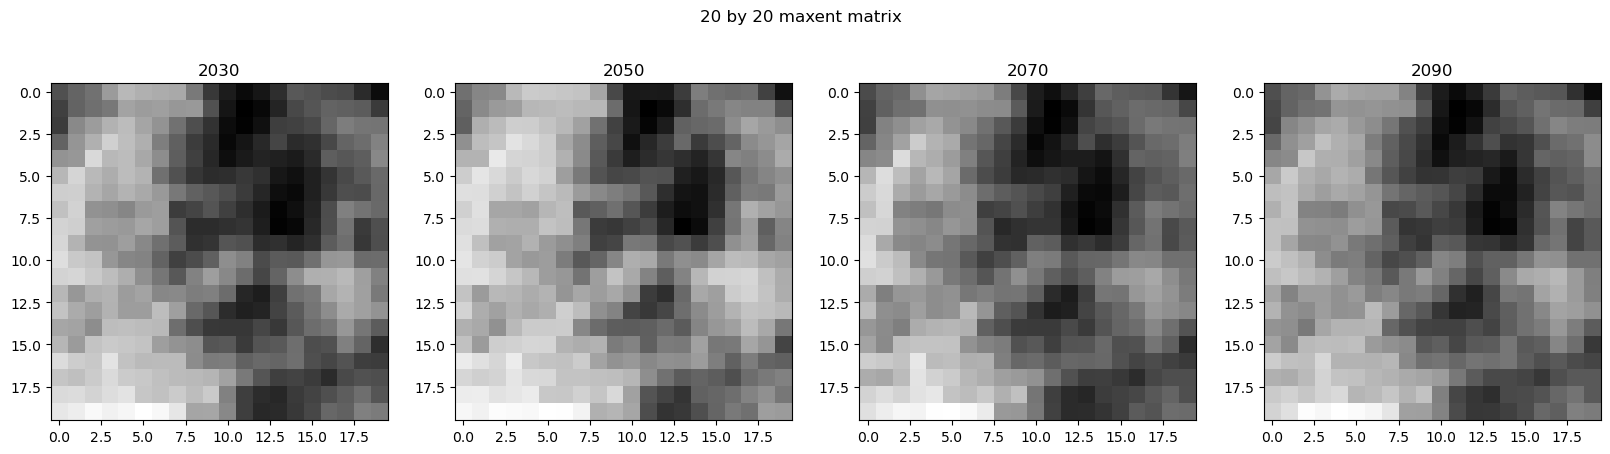

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(maxent_mat[0,:,:,0], cmap="gray")
axes[0].set_title('2030')

axes[1].imshow(maxent_mat[0,:,:,1], cmap="gray")
axes[1].set_title('2050')

axes[2].imshow(maxent_mat[0,:,:,2], cmap="gray")
axes[2].set_title('2070')

axes[3].imshow(maxent_mat[0,:,:,3], cmap="gray")
axes[3].set_title('2090')

fig.suptitle("20 by 20 maxent matrix")
plt.show()

### 멕센트로 만든 20by20 행렬의 확률 값을 바이너리로 바꾸는 함수

In [9]:
# 맥센트 확률분포 바이너리화
def get_binary_maxent_mat(maxent_mat):
    a = np.random.rand(1, 20, 20, 4) # 1, 20, 20, 4 크기의 랜덤 행렬 생성
    binary_maxent_mat = (a < maxent_mat).astype(int) # maxent_mat와 비교하여 조건을 만족하는 곳에 1을 할당
    return binary_maxent_mat

### 멕센트 데이터와 바이너리화 비교

In [10]:
def binary_maxent_mat_500(maxent_mat):
    Bmm = np.zeros((1,20,20,4))
    for e in range(500):
        binary_maxent_mat = np.array(get_binary_maxent_mat(maxent_mat), dtype=np.float32) 
        Bmm += binary_maxent_mat
    Bmm = Bmm/500
    
    return Bmm

In [11]:
Bmm = binary_maxent_mat_500(maxent_mat)

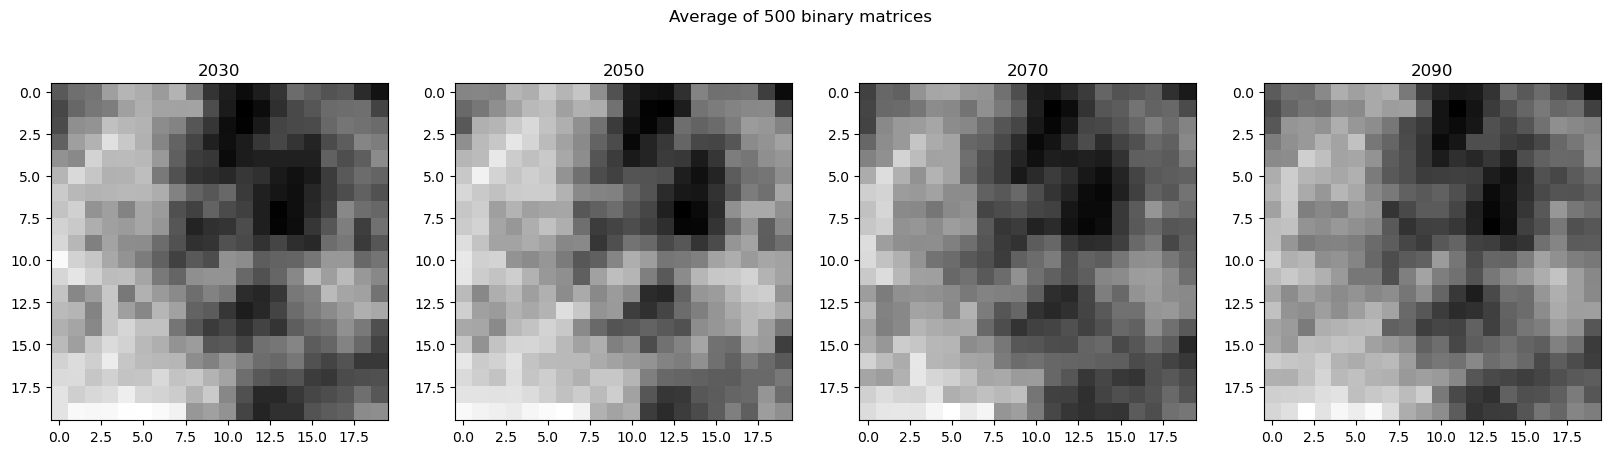

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(Bmm[0,:,:,0], cmap="gray")
axes[0].set_title('2030')

axes[1].imshow(Bmm[0,:,:,1], cmap="gray")
axes[1].set_title('2050')

axes[2].imshow(Bmm[0,:,:,2], cmap="gray")
axes[2].set_title('2070')

axes[3].imshow(Bmm[0,:,:,3], cmap="gray")
axes[3].set_title('2090')

fig.suptitle("Average of 500 binary matrices")
plt.show()

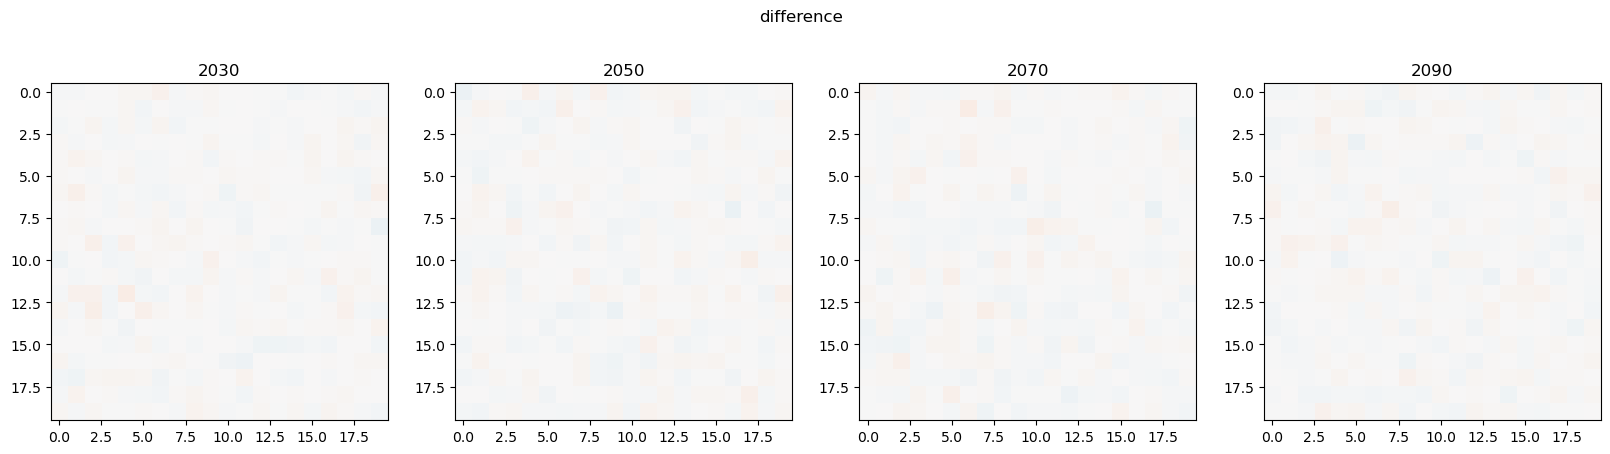

In [13]:
diff = maxent_mat - Bmm

fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1행 4열, 전체 그림 크기 조정

axes[0].imshow(diff[0,:,:,0], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title('2030')

axes[1].imshow(diff[0,:,:,1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title('2050')

axes[2].imshow(diff[0,:,:,2], cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title('2070')

axes[3].imshow(diff[0,:,:,3], cmap="RdBu_r", vmin=-1, vmax=1)
axes[3].set_title('2090')

fig.suptitle("difference")
plt.show()

### CA_distribution 구하기

In [14]:
def make_CA_distribution(maxent_mat, model):
    # distribution 구하기
    b = np.zeros((1, int(model)), dtype=np.float32)
    initial = 0
    # 500회 반복 시행
    for direc in model_dir:
        if '152' == model:
            model_call = keras.models.load_model(direc)
        else:
            model_call = keras.layers.TFSMLayer(direc, call_endpoint="serving_default")
        for e in range(100):
            binary_maxent_mat = np.array(get_binary_maxent_mat(maxent_mat), dtype=np.float32) 
            initial += np.sum(binary_maxent_mat[:,:,:,0])
            model_output = model_call(binary_maxent_mat)
            if '76' == model:
                model_output = model_output['dense_1']
            elif '152' == model:
                pass
            else:
                model_output = model_output['dense']
            model_output = np.array(model_output, dtype=np.float32)
            b += model_output
    CA_distribution = b/500
    initial = int(initial/500)
    
    return initial, CA_distribution

In [15]:
initial, CA_distribution = make_CA_distribution(maxent_mat, model[7:])

In [16]:
if '256' == model[7:]:
    labels = list(range(256))
elif '128' == model[7:]:
    labels = list(range(0,256,2))
elif '76' == model[7:]:
    labels = [0, 40, 128, 136, 160, 28, 50, 62, 94, 108, 156, 178, 18, 22, 30, 60, 90, 122, 126, 146, 150, 182, 54, 110, 238, 250, 
              254, 4, 12, 36, 44, 72, 76, 78, 104, 132, 140, 164, 200, 204, 206, 218, 222, 232, 236, 6, 26, 38, 134, 154, 158, 166,
              2, 10, 24, 42, 46, 58, 74, 130, 138, 152, 162, 170, 174, 184, 186, 188, 190, 234, 14, 168, 172, 202, 142, 106]
elif '152' == model[7:]:
    labels = [0, 40, 128, 136, 160, 28, 50, 62, 94, 108, 156, 178, 18, 22, 30, 60, 90, 122, 126, 146, 150, 182, 54, 110, 238, 250, 
              254, 4, 12, 36, 44, 72, 76, 78, 104, 132, 140, 164, 200, 204, 206, 218, 222, 232, 236, 6, 26, 38, 134, 154, 158, 166, 
              2, 10, 24, 42, 46, 58, 74, 130, 138, 152, 162, 170, 174, 184, 186, 188, 190, 234, 14, 168, 172, 202, 142, 106, 
              1, 41, 129, 137, 161, 29, 51, 63, 95, 109, 157, 179, 19, 23, 31, 61, 91, 123, 127, 147, 151, 183, 55, 111, 239, 251, 
              255, 5, 13, 37, 45, 73, 77, 79, 105, 133, 141, 165, 201, 205, 207, 219, 223, 233, 237, 7, 27, 39, 135, 155, 159, 167, 
              3, 11, 25, 43, 47, 59, 75, 131, 139, 153, 163, 171, 175, 185, 187, 189, 191, 235, 15, 169, 173, 203, 143, 107]
else:
    print('label wrong..')

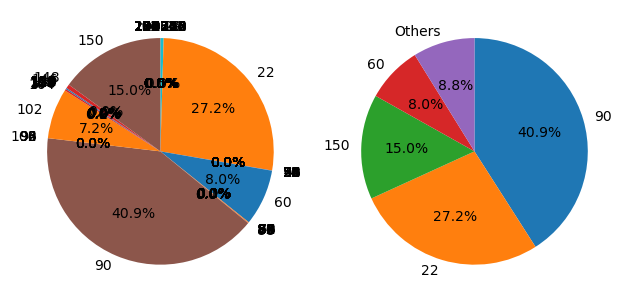

In [17]:
fig, axes = plt.subplots(1, 2) #, figsize=(12, 6))  # 1행 2열의 서브플롯 생성 (가로로 배치)

data = CA_distribution[0]

# 일반적인 원그래프
axes[0].pie(data, labels=labels ,autopct='%.1f%%', startangle=90, counterclock=False)

# 상위만 그린 원그래프
# 데이터와 레이블을 내림차순으로 정렬
sorted_indices = np.argsort(data)[::-1]
sorted_data = data[sorted_indices]
sorted_labels = np.array(labels)[sorted_indices]

# 상위 5개 항목만 선택
top_n = 4
top_data = sorted_data[:top_n]
top_labels = sorted_labels[:top_n]

# 나머지 항목을 "기타"로 처리
other_data = np.sum(sorted_data[top_n:])
other_label = 'Others'

# "기타" 항목 추가
final_data = np.append(top_data, other_data)
final_labels = np.append(top_labels, other_label)

# 파이 차트 그리기
axes[1].pie(final_data, labels=final_labels, autopct='%.1f%%', startangle=90, counterclock=False)

plt.tight_layout()  # 레이아웃 조정
plt.show()

### SI 구하기

In [18]:
weight = np.load(base+'/WeightByInitial.npy', allow_pickle=True)

In [19]:
def clu_SI(initial, CA_distribution):
    global weight, labels
    SI = 0
    for k, i in enumerate(labels):  # k는 인덱스, i는 labels의 값
        si = CA_distribution[0][k] * weight[i][initial]  # 각 원소를 선택하여 저장
        SI += si
        
    # # 전체 면적으로 나눌 때    
    SI = SI/400
    # # 초기갑으로 나눌 때
    # if initial != 0:
    #     SI = SI / initial
    # else:
    #     SI = 0
    
    return SI

In [20]:
clu_SI(initial, CA_distribution)

np.float64(0.4444116728233726)

### 모든 시나리오 별 각 행정구역의 값 계산

In [21]:
scenarios = [['126','126','126','126'],['126','126','126','245'],['126','126','126','585'],['126','126','245','126'],['126','126','245','245'],['126','126','245','585'],['126','126','585','126'],['126','126','585','245'],['126','126','585','585'],
             ['126','245','126','126'],['126','245','126','245'],['126','245','126','585'],['126','245','245','126'],['126','245','245','245'],['126','245','245','585'],['126','245','585','126'],['126','245','585','245'],['126','245','585','585'],
             ['126','585','126','126'],['126','585','126','245'],['126','585','126','585'],['126','585','245','126'],['126','585','245','245'],['126','585','245','585'],['126','585','585','126'],['126','585','585','245'],['126','585','585','585'],
             ['245','126','126','126'],['245','126','126','245'],['245','126','126','585'],['245','126','245','126'],['245','126','245','245'],['245','126','245','585'],['245','126','585','126'],['245','126','585','245'],['245','126','585','585'],
             ['245','245','126','126'],['245','245','126','245'],['245','245','126','585'],['245','245','245','126'],['245','245','245','245'],['245','245','245','585'],['245','245','585','126'],['245','245','585','245'],['245','245','585','585'],
             ['245','585','126','126'],['245','585','126','245'],['245','585','126','585'],['245','585','245','126'],['245','585','245','245'],['245','585','245','585'],['245','585','585','126'],['245','585','585','245'],['245','585','585','585'],
             ['585','126','126','126'],['585','126','126','245'],['585','126','126','585'],['585','126','245','126'],['585','126','245','245'],['585','126','245','585'],['585','126','585','126'],['585','126','585','245'],['585','126','585','585'],
             ['585','245','126','126'],['585','245','126','245'],['585','245','126','585'],['585','245','245','126'],['585','245','245','245'],['585','245','245','585'],['585','245','585','126'],['585','245','585','245'],['585','245','585','585'],
             ['585','585','126','126'],['585','585','126','245'],['585','585','126','585'],['585','585','245','126'],['585','585','245','245'],['585','585','245','585'],['585','585','585','126'],['585','585','585','245'],['585','585','585','585']]

In [45]:
# # 각 시나리오마다 각 행정구역의 데이터를 만듭니다. 12분*81 정도의 시간이 걸립니다.
# with h5py.File(base+'/All_data.h5', 'w') as f:
#     for scenario in tqdm(scenarios):
#         # 각 시나리오별로 그룹 생성
#         scenario_name = str(scenario[0])+'_'+str(scenario[1])+'_'+str(scenario[2])+'_'+str(scenario[3])
#         scenario_group = f.create_group(f'{scenario_name}')
#         for loc in local_name:
#             maxent_mat = make_maxent_mat(scenario, loc)
#             initial, CA_distribution = make_CA_distribution(maxent_mat, int(model[7:]))
#             SI = clu_SI(initial, CA_distribution)
#             # 각 행정구역별로 하위그룹 생성
#             loc_group = scenario_group.create_group(f'{loc}')
#             loc_group.create_dataset('initial', data=initial)
#             loc_group.create_dataset('CA_distribution', data=CA_distribution)
#             loc_group.create_dataset('SI', data=SI)

In [23]:
# 시나리오별 처리 함수 정의
def process_scenario(scenario, base, local_name, model):
    # 파일을 추가 모드로 열기
    with h5py.File(base+'/'+model[7:]+'_data_'+sampling[6:]+'.h5', 'a') as f:
        scenario_name = str(scenario[0])+'_'+str(scenario[1])+'_'+str(scenario[2])+'_'+str(scenario[3])
        # 이미 처리된 시나리오인지 확인
        if scenario_name in f:
            print(f"시나리오 {scenario_name}은 이미 처리되었습니다. 건너뜁니다.")
            return
        # 새 시나리오 그룹 생성
        scenario_group = f.create_group(f'{scenario_name}')
        # 이 시나리오의 모든 지역 처리
        for loc in local_name:
            maxent_mat = make_maxent_mat(scenario, loc)
            initial, CA_distribution = make_CA_distribution(maxent_mat, model[7:])
            SI = clu_SI(initial, CA_distribution)
            # 각 행정구역별 하위그룹 생성
            loc_group = scenario_group.create_group(f'{loc}')
            loc_group.create_dataset('initial', data=initial)
            loc_group.create_dataset('CA_distribution', data=CA_distribution)
            loc_group.create_dataset('SI', data=SI)
        print(f"시나리오 {scenario_name} 완료 및 저장됨")

In [ ]:
# 파일이 없으면 새로 생성
import os
if not os.path.exists(base+'/'+model[7:]+'_data_'+sampling[6:]+'.h5'):
    with h5py.File(base+'/'+model[7:]+'_data_'+sampling[6:]+'.h5', 'w') as f:
        pass  # 빈 파일 생성
# 모든 시나리오 처리
for scenario in tqdm(scenarios, desc="전체 시나리오 처리 중"):
    process_scenario(scenario, base, local_name, model)

전체 시나리오 처리 중:   1%|          | 1/81 [09:52<13:09:22, 592.04s/it]

시나리오 126_126_126_126 완료 및 저장됨


전체 시나리오 처리 중:   2%|▏         | 2/81 [19:16<12:38:10, 575.83s/it]

시나리오 126_126_126_245 완료 및 저장됨


전체 시나리오 처리 중:   4%|▎         | 3/81 [28:34<12:17:43, 567.48s/it]

...

시나리오 585_585_245_585 완료 및 저장됨


전체 시나리오 처리 중:  98%|█████████▊| 79/81 [12:25:15<19:45, 592.66s/it]

시나리오 585_585_585_126 완료 및 저장됨


전체 시나리오 처리 중:  99%|█████████▉| 80/81 [12:35:09<09:53, 593.04s/it]

시나리오 585_585_585_245 완료 및 저장됨


In [21]:
# 데이터가 잘 만들어서 저장되어 있는지 확인합니다.
with h5py.File(base+'/'+model[7:]+'_data_'+sampling[6:]+'.h5', 'r') as f:
    # 그룹에 접근
    inje_group = f['585_585_585_585']['Inje-gun1']
    # 각 데이터셋 접근
    ca_distribution = inje_group['CA_distribution'][()]
    si_data = inje_group['SI'][()]
    initial_data = inje_group['initial'][()]
    
    # 데이터 확인
    print("CA_distribution 데이터:", ca_distribution.shape)
    print(ca_distribution)
    print("\nSI 데이터:")
    print(si_data)
    print("\ninitial 데이터:")
    print(initial_data)

CA_distribution 데이터: (1, 128)
[[1.4004273e-12 1.3984296e-10 3.7128194e-09 3.5707882e-05 6.6263581e-08
  1.3471026e-06 5.5485152e-08 8.3712017e-05 6.1475612e-12 3.8094096e-02
  8.6095417e-05 6.2352163e-01 5.4842116e-07 4.4116024e-03 2.8618305e-07
  9.9758524e-04 6.9998123e-08 1.7380400e-10 1.7838818e-08 7.1288717e-08
  6.6181009e-08 9.0959835e-09 2.1483047e-06 2.3514302e-07 4.6762919e-12
  2.5421429e-07 3.6020751e-08 1.7375016e-03 2.8750614e-07 1.5409500e-09
  2.3407379e-02 1.1539018e-08 6.7447161e-08 3.0483423e-07 2.0099930e-04
  2.9627557e-07 1.1997628e-09 7.7548080e-05 9.5311997e-08 2.9272751e-10
  1.1268415e-06 3.0984592e-03 5.2216132e-05 5.3904387e-05 3.1621177e-05
  1.7413373e-01 5.5791105e-09 3.1576391e-07 6.9522628e-08 3.3894858e-07
  4.0953184e-04 2.6235621e-02 3.0906826e-09 3.1226594e-03 5.3176072e-06
  1.0525364e-04 1.1280654e-09 4.4696327e-09 2.5374097e-06 1.7761401e-08
  7.6847890e-04 8.2211562e-07 7.5011274e-05 4.4703080e-07 7.2513338e-08
  1.9452397e-08 9.1868721e-08 4.41

In [ ]:
#SI 데이터만 추출하여 저장합니다.
with h5py.File(base+'/'+model[7:]+'_data_'+sampling[6:]+'.h5', 'r') as f:
    # 최상위 키(시나리오 목록) 가져오기
    scenarios = list(f.keys())
    locs = list(f[scenarios[0]].keys())
    df = pd.DataFrame(index=locs, columns=scenarios)
    for scenario in scenarios:
        for loc in locs:
            df.loc[loc, scenario] = f[scenario][loc]['SI'][()]
df.to_csv(base+'/'+model[7:]+'_SI_data_'+sampling[6:]+'.csv')

In [ ]:
# 걸리는 시간을 알고 싶을 때 사용
start_time = time.time()

# 여기에 시간을 측정하고 싶은 코드를 넣습니다.

end_time = time.time()
execution_time = end_time - start_time
print(f"함수 실행 시간: {execution_time:.6f}초")